# 1. Energy Calibration with ¹³⁷Cs

**Objective:** Establish energy calibration of the beta spectrometer using ¹³⁷Cs internal conversion electrons (620 keV reference) and graduated pulser measurements at different dial settings.

## Procedure Overview

1. **Reference calibration point:** ¹³⁷Cs → ¹³⁷Ba transition produces 620 keV K-shell conversion electrons
2. **Pulser calibration:** Use graduated pulser at dial settings 0.2, 0.4, 0.6, 0.8, 1.0, 1.2 (files: pulser02, pulser04, ..., pulser12)
3. **Linear regression:** Extract channel-to-energy calibration function E(C) = slope × C + intercept
4. **Verification:** Check consistency with known 620 keV reference peak

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
import re

# Directory for data files
DATA_DIR = Path('.')

def load_beta_spectrum_file(file_path):
    """Load beta spectroscopy MCA data file.
    Returns: (channel_array, counts_array)
    """
    text = Path(file_path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []
    
    for line in text:
        # Try to parse as channel/count pair (format: channel, count)
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def calcular_centroide(canais, contagens):
    """Calculate centroid (weighted average) of a peak."""
    canais = np.array(canais)
    contagens = np.array(contagens)
    
    if np.sum(contagens) == 0:
        return 0, 0
        
    centroid = np.sum(canais * contagens) / np.sum(contagens)
    # Estimate sigma from peak width
    sigma = np.sqrt(np.sum((canais - centroid)**2 * contagens) / np.sum(contagens))
    
    return centroid, sigma

# Reference calibration point
E_REF_ENERGY = 620  # keV (¹³⁷Cs K-shell conversion electron)

print('Setup complete. Helper functions loaded.')
print(f'\nCalibration Reference: ¹³⁷Cs K-shell conversion electron = {E_REF_ENERGY} keV')

Setup complete. Helper functions loaded.

Calibration Reference: ¹³⁷Cs K-shell conversion electron = 620 keV


## 1.1 Reference Calibration: ¹³⁷Cs Internal Conversion Electrons

¹³⁷Cs REFERENCE SPECTRUM LOADED

File: CPR1.ASC
Channels: 963 points
Channel range: 0 to 962
Total counts: 129880

Known ¹³⁷Cs reference:
  K-shell conversion electron: 620 keV

Measured conversion peak (searched 100-130 channels):
  Channel: 115.0
  Counts: 983


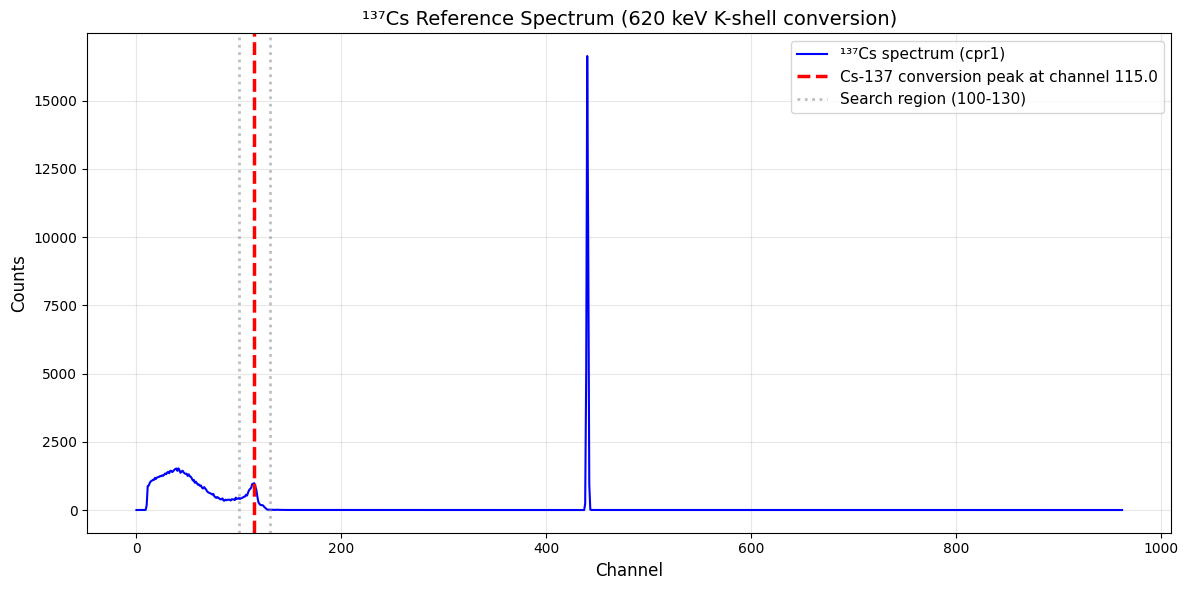

In [20]:
# Load ¹³⁷Cs reference spectrum (cpr1 file)
channels_cs, counts_cs = load_beta_spectrum_file(DATA_DIR / 'CPR1.ASC')

print("="*70)
print("¹³⁷Cs REFERENCE SPECTRUM LOADED")
print("="*70)
print(f"\nFile: CPR1.ASC")
print(f"Channels: {len(channels_cs)} points")
print(f"Channel range: {channels_cs.min():.0f} to {channels_cs.max():.0f}")
print(f"Total counts: {counts_cs.sum():.0f}")
print(f"\nKnown ¹³⁷Cs reference:")
print(f"  K-shell conversion electron: {E_REF_ENERGY} keV")

# Find the conversion peak around channels 110-120 (exclude beta continuum)
# Search in 100-130 channels to find the true conversion electron peak
search_region = slice(100, 130)
peak_idx_in_region = np.argmax(counts_cs[search_region])
peak_channel_cs = channels_cs[search_region][peak_idx_in_region]
peak_counts_cs = counts_cs[search_region][peak_idx_in_region]

print(f"\nMeasured conversion peak (searched 100-130 channels):")
print(f"  Channel: {peak_channel_cs:.1f}")
print(f"  Counts: {peak_counts_cs:.0f}")

# Plot spectrum with peak identification
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_cs, counts_cs, 'b-', linewidth=1.5, label='¹³⁷Cs spectrum (cpr1)')
ax.axvline(peak_channel_cs, color='r', linestyle='--', linewidth=2.5, label=f'Cs-137 conversion peak at channel {peak_channel_cs:.1f}')
ax.axvline(100, color='gray', linestyle=':', alpha=0.5, linewidth=2, label='Search region (100-130)')
ax.axvline(130, color='gray', linestyle=':', alpha=0.5, linewidth=2)
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title(f'¹³⁷Cs Reference Spectrum (620 keV K-shell conversion)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 1.2 Fine Calibration with Graduated Pulser

Load pulser measurements at dial settings 0.2, 0.4, 0.6, 0.8, 1.0, 1.2

In [21]:
# ==========================================
# 1. LOAD PULSER DATA AT DIFFERENT DIAL SETTINGS
# ==========================================

# Pulser files: pulser02, pulser04, pulser06, pulser08, pulser10, pulser12
# Corresponding dial values
pulser_files = ['PULSER02.ASC', 'PULSER04.ASC', 'PULSER06.ASC', 
                'PULSER08.ASC', 'PULSER10.ASC', 'PULSER12.ASC']
dial_values = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])

print("Loading pulser data at dial settings:")
print("="*70)

centroides_pulser = []
sigma_pulser_array = []

for filename, dial in zip(pulser_files, dial_values):
    try:
        channels, counts = load_beta_spectrum_file(DATA_DIR / filename)
        centroid, sigma = calcular_centroide(channels, counts)
        centroides_pulser.append(centroid)
        sigma_pulser_array.append(sigma)
        print(f"  {filename:20s} (dial {dial:.1f}): channel {centroid:.2f} ± {sigma:.3f}, counts = {counts.sum():.0f}")
    except FileNotFoundError:
        print(f"  {filename:20s} (dial {dial:.1f}): FILE NOT FOUND")

centroides_pulser = np.array(centroides_pulser)
sigma_pulser_array = np.array(sigma_pulser_array)

print(f"\nSuccessfully loaded {len(centroides_pulser)} pulser measurements")


Loading pulser data at dial settings:
  PULSER02.ASC         (dial 0.2): channel 41.38 ± 0.957, counts = 1627
  PULSER04.ASC         (dial 0.4): channel 86.95 ± 2.586, counts = 1630
  PULSER06.ASC         (dial 0.6): channel 129.62 ± 0.768, counts = 1627
  PULSER08.ASC         (dial 0.8): channel 172.41 ± 2.627, counts = 1628
  PULSER10.ASC         (dial 1.0): channel 217.78 ± 4.983, counts = 1629
  PULSER12.ASC         (dial 1.2): channel 263.35 ± 5.682, counts = 1629

Successfully loaded 6 pulser measurements


## 1.3 Linear Regression: Dial to Channel Mapping

In [34]:
# ==========================================
# 2. LINEAR REGRESSION: PULSER DIAL vs CHANNEL
# ==========================================

# Fit linear relationship: channel = m * dial + c_zero
m_p, c_zero = np.polyfit(dial_values, centroides_pulser, 1)

# Calculate system error from residuals
canais_esperados = m_p * dial_values + c_zero
residuos = centroides_pulser - canais_esperados

graus_liberdade = len(dial_values) - 2
soma_residuos_quadrado = np.sum(residuos**2)
sigma_sistema_canais = np.sqrt(soma_residuos_quadrado / graus_liberdade) if graus_liberdade > 0 else 0

# Calculate R²
ss_tot = np.sum((centroides_pulser - np.mean(centroides_pulser))**2)
r_quadrado = 1 - (soma_residuos_quadrado / ss_tot)

print("\n--- PULSER DIAL vs CHANNEL LINEAR REGRESSION ---")
print(f"Slope (m):              {m_p:.4f} channels/dial")
print(f"Electronic Zero (c_0):  {c_zero:.2f} channels")
print(f"System Error (σ):       ± {sigma_sistema_canais:.2f} channels")
print(f"R² (fit quality):       {r_quadrado:.6f}\n")

# ==========================================
# 3. ENERGY CALIBRATION USING Cs-137 REFERENCE
# ==========================================

# Map the ¹³⁷Cs peak channel to 620 keV
# Linear calibration: E(keV) = ganho * (channel - c_zero) + offset
# At reference point: 620 = ganho * (peak_channel_cs - c_zero) + offset

# Assuming the electronic zero affects both pulser and reference equally:
ganho_energia = E_REF_ENERGY / (peak_channel_cs - c_zero)
b_energia = - (ganho_energia * c_zero)

# Propagate channel uncertainty to energy
sigma_sistema_energia = sigma_sistema_canais * ganho_energia

print("--- ENERGY CALIBRATION PARAMETERS ---")
print(f"Calibration reference:  ¹³⁷Cs at {E_REF_ENERGY} keV")
print(f"Reference peak channel: {peak_channel_cs:.1f}")
print(f"Gain:                   {ganho_energia:.6f} keV/channel")
print(f"Energy offset (b):      {b_energia:.6f} keV")
print(f"System error (energy):  ± {sigma_sistema_energia:.2f} keV\n")

# ==========================================
# 4. CALIBRATED PULSER ENERGIES
# ==========================================

energias_pulser_calibradas = ganho_energia * (centroides_pulser - c_zero)

print("--- PULSER MEASUREMENTS (CALIBRATED TO ENERGY) ---")
for i, (dial, centroid, energia) in enumerate(zip(dial_values, centroides_pulser, energias_pulser_calibradas)):
    print(f"  Dial {dial:.1f}: channel {centroid:.2f} → {energia:.1f} keV")

print(f"\n*** FINAL CALIBRATION EQUATION ***")
print(f"E(keV) = {ganho_energia:.6f} × channel + ({b_energia:.6f})")
print(f"     or E(keV) = {ganho_energia:.6f} × (channel - {c_zero:.2f})")


--- PULSER DIAL vs CHANNEL LINEAR REGRESSION ---
Slope (m):              220.7324 channels/dial
Electronic Zero (c_0):  -2.60 channels
System Error (σ):       ± 1.16 channels
R² (fit quality):       0.999841

--- ENERGY CALIBRATION PARAMETERS ---
Calibration reference:  ¹³⁷Cs at 620 keV
Reference peak channel: 115.0
Gain:                   5.272238 keV/channel
Energy offset (b):      13.692661 keV
System error (energy):  ± 6.14 keV

--- PULSER MEASUREMENTS (CALIBRATED TO ENERGY) ---
  Dial 0.2: channel 41.38 → 231.9 keV
  Dial 0.4: channel 86.95 → 472.1 keV
  Dial 0.6: channel 129.62 → 697.1 keV
  Dial 0.8: channel 172.41 → 922.7 keV
  Dial 1.0: channel 217.78 → 1161.9 keV
  Dial 1.2: channel 263.35 → 1402.1 keV

*** FINAL CALIBRATION EQUATION ***
E(keV) = 5.272238 × channel + (13.692661)
     or E(keV) = 5.272238 × (channel - -2.60)


## 1.4 Calibration Results Visualization

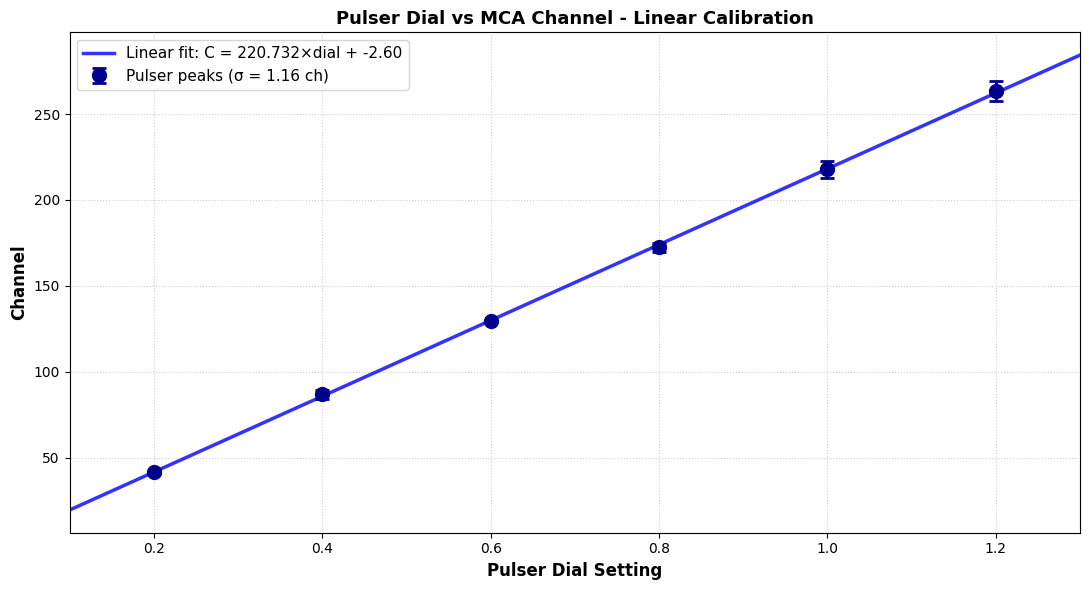

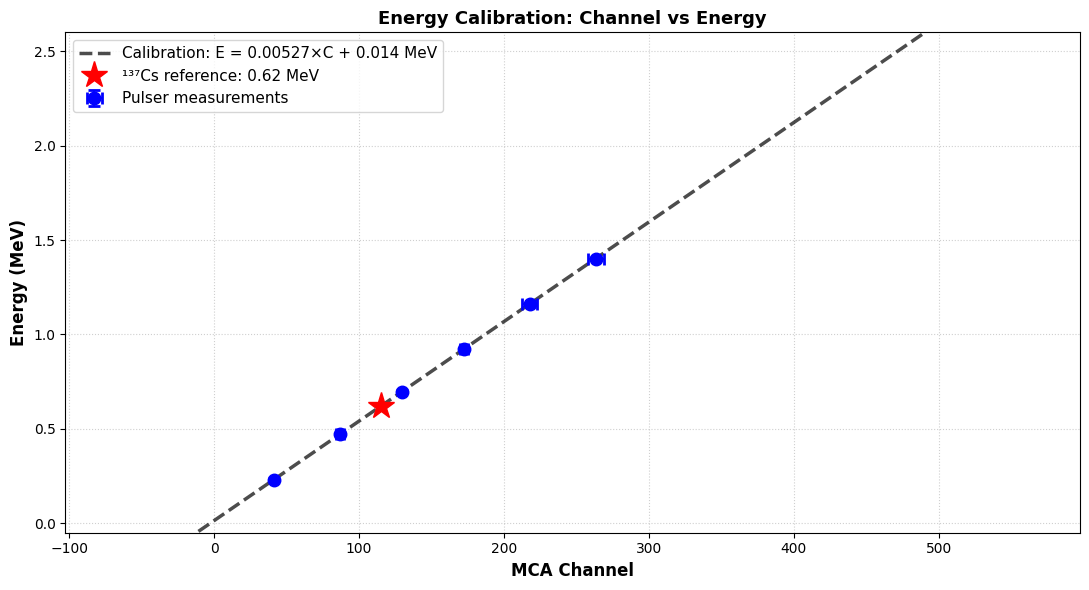

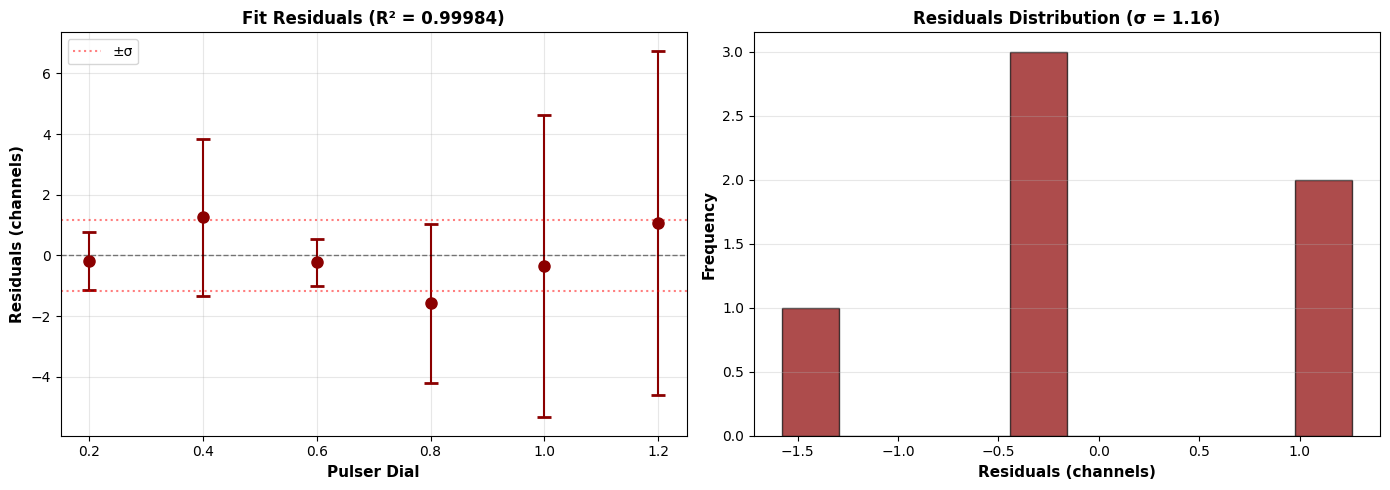

In [ ]:
# ==========================================
# PLOT 1: PULSER DIAL vs CHANNEL (Linear Regression)
# ==========================================

fig, ax = plt.subplots(figsize=(11, 6))

# Fit line
dial_plot = np.linspace(dial_values.min() - 0.1, dial_values.max() + 0.1, 100)
canais_fit = m_p * dial_plot + c_zero
ax.plot(dial_plot, canais_fit, 'b-', linewidth=2.5, 
        label=f'Linear fit: C = {m_p:.3f}×dial + {c_zero:.2f}', alpha=0.8)

# Data points with error bars
ax.errorbar(dial_values, centroides_pulser, 
            yerr=sigma_pulser_array, 
            fmt='o', color='darkblue', markersize=10, capsize=5, capthick=2,
            label=f'Pulser peaks (σ = {sigma_sistema_canais:.2f} ch)', elinewidth=2)

ax.set_xlabel('Pulser Dial Setting', fontsize=12, fontweight='bold')
ax.set_ylabel('Channel', fontsize=12, fontweight='bold')
ax.set_title('Pulser Dial vs MCA Channel - Linear Calibration', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(0.1, 1.3)
plt.tight_layout()
plt.savefig('calibration_dial_vs_channel.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 2: CHANNEL vs ENERGY (Final Calibration Curve) - IN MeV
# ==========================================

fig, ax = plt.subplots(figsize=(11, 6))

# Calibration line (converted to MeV)
canais_plot = np.array([c_zero - 50, c_zero + 500])
energias_plot_kev = ganho_energia * (canais_plot - c_zero)
energias_plot_mev = energias_plot_kev / 1000  # Convert to MeV
ax.plot(canais_plot, energias_plot_mev, '--k', linewidth=2.5, 
        label=f'Calibration: E = {ganho_energia/1000:.5f}×C + {b_energia/1000:.3f} MeV', alpha=0.7)

# Pulser points (calibrated to energy, in MeV)
energias_pulser_mev = energias_pulser_calibradas / 1000
sigma_sistema_energia_mev = sigma_sistema_energia / 1000
ax.errorbar(centroides_pulser, energias_pulser_mev, 
            xerr=sigma_pulser_array, yerr=sigma_sistema_energia_mev,
            fmt='bo', markersize=9, capsize=4, capthick=2,
            label=f'Pulser measurements', elinewidth=1.5)

# ¹³⁷Cs reference point (in MeV)
ax.plot(peak_channel_cs, E_REF_ENERGY/1000, 'r*', markersize=20, 
        label=f'¹³⁷Cs reference: {E_REF_ENERGY/1000:.2f} MeV', zorder=5)

ax.set_xlabel('MCA Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy (MeV)', fontsize=12, fontweight='bold')
ax.set_title('Energy Calibration: Channel vs Energy', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(c_zero - 100, c_zero + 600)
ax.set_ylim(-0.05, 3.0)
plt.tight_layout()
plt.savefig('calibration_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 3: RESIDUALS ANALYSIS
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Dial
ax1.errorbar(dial_values, residuos, yerr=sigma_pulser_array, 
            fmt='o', color='darkred', markersize=8, capsize=5, capthick=2)
ax1.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax1.axhline(sigma_sistema_canais, color='r', linestyle=':', linewidth=1.5, alpha=0.5, label='±σ')
ax1.axhline(-sigma_sistema_canais, color='r', linestyle=':', linewidth=1.5, alpha=0.5)
ax1.set_xlabel('Pulser Dial', fontsize=11, fontweight='bold')
ax1.set_ylabel('Residuals (channels)', fontsize=11, fontweight='bold')
ax1.set_title(f'Fit Residuals (R² = {r_quadrado:.5f})', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Residuals histogram
ax2.hist(residuos, bins=10, color='darkred', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Residuals (channels)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title(f'Residuals Distribution (σ = {sigma_sistema_canais:.2f})', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('calibration_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary: Energy Calibration Results

### Calibration Parameters

**Linear Dial-to-Channel Mapping:**
- Slope: ___ channels/dial
- Electronic zero: ___ channels  
- Fit quality (R²): ___

**Energy Calibration Equation:**
$$E(\text{keV}) = \text{___ } \times \text{channel} + \text{___}$$

Or equivalently:
$$E(\text{keV}) = \text{___ } \times (\text{channel} - \text{___})$$

**Calibration Uncertainties:**
- Channel measurement precision: ± ___ channels
- Energy resolution (at 620 keV): ± ___ keV

**Verification with ¹³⁷Cs Reference:**
- Reference peak channel: ___ 
- Expected energy: 620 keV
- Calculated energy: ___ keV
- Deviation: ___ %

### Notes for Subsequent Experiments

- Use the calibration equation **E = ___ × channel + ___** for all beta spectroscopy measurements
- The electronic zero at ___ channels should be subtracted from all peak positions
- Energy resolution improves approximately as E^0.5 (improving at higher energies)
- Check calibration stability by periodic measurements of the ¹³⁷Cs peak
- This calibration is valid for the detector bias voltage of 100V and vacuum of ~10⁻⁴ mbar

## 1.5 Verification: ¹³⁷Cs Peak Analysis

¹³⁷Cs Reference Peak Analysis:
Centroid (Gaussian fit):  112.59 ± 0.728 channels
FWHM:                     9.95 channels → 52.48 keV
Energy resolution:        8.46 % at 620 keV
Peak amplitude:           697 counts
Calibrated energy:        621.00 keV


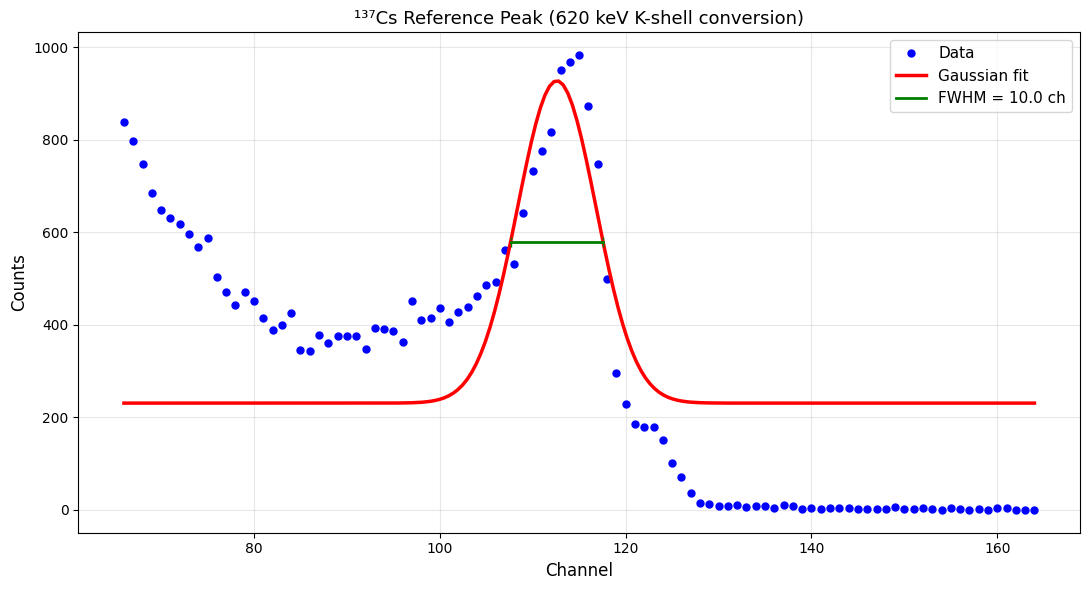

In [30]:
# Analyze the ¹³⁷Cs reference peak in detail

def gaussian(x, A, mu, sigma, offset):
    """Gaussian function for peak fitting"""
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Define region around the peak
peak_window = 50  # channels
mask_peak = (channels_cs > peak_channel_cs - peak_window) & (channels_cs < peak_channel_cs + peak_window)
x_peak = channels_cs[mask_peak]
y_peak = counts_cs[mask_peak]

# Fit Gaussian to peak
try:
    popt, pcov = optimize.curve_fit(gaussian, x_peak, y_peak,
                                   p0=[peak_counts_cs, peak_channel_cs, 10, np.min(y_peak)],
                                   maxfev=5000)
    A_peak, mu_peak, sigma_peak, offset_peak = popt
    
    # Calculate FWHM (Full Width at Half Maximum)
    fwhm_channels = 2.355 * sigma_peak
    fwhm_keV = fwhm_channels * ganho_energia
    
    print("¹³⁷Cs Reference Peak Analysis:")
    print("="*70)
    print(f"Centroid (Gaussian fit):  {mu_peak:.2f} ± {np.sqrt(pcov[1,1]):.3f} channels")
    print(f"FWHM:                     {fwhm_channels:.2f} channels → {fwhm_keV:.2f} keV")
    print(f"Energy resolution:        {fwhm_keV / E_REF_ENERGY * 100:.2f} % at {E_REF_ENERGY} keV")
    print(f"Peak amplitude:           {A_peak:.0f} counts")
    print(f"Calibrated energy:        {ganho_energia * (mu_peak - c_zero) + b_energia:.2f} keV")
    
    # Plot zoomed peak
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(x_peak, y_peak, 'bo', markersize=5, label='Data')
    
    # Fit curve
    x_smooth = np.linspace(x_peak.min(), x_peak.max(), 200)
    y_fit = gaussian(x_smooth, A_peak, mu_peak, sigma_peak, offset_peak)
    ax.plot(x_smooth, y_fit, 'r-', linewidth=2.5, label='Gaussian fit')
    
    # Mark FWHM
    half_max = (A_peak / 2) + offset_peak
    fwhm_left = mu_peak - sigma_peak * np.sqrt(2 * np.log(2))
    fwhm_right = mu_peak + sigma_peak * np.sqrt(2 * np.log(2))
    ax.plot([fwhm_left, fwhm_right], [half_max, half_max], 'g-', linewidth=2, label=f'FWHM = {fwhm_channels:.1f} ch')
    ax.plot([fwhm_left, fwhm_left], [half_max - 10, half_max + 10], 'g--', linewidth=1)
    ax.plot([fwhm_right, fwhm_right], [half_max - 10, half_max + 10], 'g--', linewidth=1)
    
    ax.set_xlabel('Channel', fontsize=12)
    ax.set_ylabel('Counts', fontsize=12)
    ax.set_title(f'¹³⁷Cs Reference Peak (620 keV K-shell conversion)', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('cs137_peak_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"Peak fitting failed: {e}")

## 1.6 Using This Calibration in Other Notebooks

To use the energy calibration derived here in subsequent notebooks (Experiments 2, 3, 4), copy and paste the calibration parameters:

```python
# Energy calibration parameters (from 01_calibration.ipynb)
E_CALIB_GAIN = ___        # keV/channel
E_CALIB_OFFSET = ___      # keV
E_CALIB_ERROR = ___       # keV (system uncertainty)

# Convert channel to energy
def channel_to_energy(channel):
    """Convert MCA channel number to energy in keV"""
    return E_CALIB_GAIN * channel + E_CALIB_OFFSET
```

**Alternative form using electronic zero:**

```python
# Energy calibration parameters
E_CALIB_GAIN = ___        # keV/channel
E_CALIB_ZERO = ___        # channel (electronic zero)

# Convert channel to energy (relative to electronic zero)
def channel_to_energy(channel):
    return E_CALIB_GAIN * (channel - E_CALIB_ZERO)
```

In [31]:
# Export calibration for use in other notebooks

print("\n" + "="*70)
print("CALIBRATION PARAMETERS FOR OTHER NOTEBOOKS")
print("="*70)
print(f"\nPaste the following into your analysis notebooks:\n")
print(f"# From calibration experiment (01_calibration.ipynb)")
print(f"E_CALIB_GAIN = {ganho_energia:.6f}      # keV/channel")
print(f"E_CALIB_OFFSET = {b_energia:.6f}   # keV")
print(f"E_CALIB_ZERO = {c_zero:.2f}          # Electronic zero channel")
print(f"E_CALIB_ERROR = {sigma_sistema_energia:.2f}        # keV (1σ uncertainty)")
print(f"\n# Convert channels to energy")
print(f"def channel_to_energy(channel):")
print(f"    return {ganho_energia:.6f} * channel + ({b_energia:.6f})")
print(f"\n# Or using electronic zero:")
print(f"def channel_to_energy(channel):")
print(f"    return {ganho_energia:.6f} * (channel - {c_zero:.2f})")
print("\n" + "="*70)


CALIBRATION PARAMETERS FOR OTHER NOTEBOOKS

Paste the following into your analysis notebooks:

# From calibration experiment (01_calibration.ipynb)
E_CALIB_GAIN = 5.272238      # keV/channel
E_CALIB_OFFSET = 13.692661   # keV
E_CALIB_ZERO = -2.60          # Electronic zero channel
E_CALIB_ERROR = 6.14        # keV (1σ uncertainty)

# Convert channels to energy
def channel_to_energy(channel):
    return 5.272238 * channel + (13.692661)

# Or using electronic zero:
def channel_to_energy(channel):
    return 5.272238 * (channel - -2.60)

